# Análisis exploratorio de datos de TRIP

Este notebook analiza perfiles, partidas, productos y compras del videojuego TRIP. El flujo incluye calidad de datos, estadística descriptiva, análisis temporal, actividad por mapa, retención y monetización.

Los datos deben exportarse desde Supabase y colocarse en `data/raw/` antes de ejecutar las celdas de análisis. No se deben inventar resultados: si falta un archivo, el notebook lo reportará como pendiente.

## 1. Preguntas de negocio

- ¿Cuántos usuarios están activos por mes?
- ¿Cuál es la retención D1, D7 y D30?
- ¿Qué productos generan más compras e ingresos?
- ¿Qué mapas concentran más partidas?
- ¿En qué días y horarios se concentra la actividad?
- ¿Cómo se comportan los jugadores nuevos frente a los recurrentes?

In [1]:
from pathlib import Path
%pip install pandas
import pandas as pd
%pip install matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'Datos raw: {RAW_DIR.resolve()}')
print(f'Archivos disponibles: {sorted(path.name for path in RAW_DIR.glob("*.csv"))}')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Datos raw: C:\Users\Andyl\Downloads\TRIP\vite-project\data\raw
Archivos disponibles: ['game_matches.csv', 'products.csv', 'profiles.csv', 'purchases.csv']


## 2. Carga de datos

Exporta estas tablas como CSV desde Supabase:

- `profiles.csv`
- `products.csv`
- `purchases.csv`
- `game_matches.csv`
- `progress.csv` (opcional)

La carga es tolerante a archivos ausentes para permitir avanzar por etapas.

In [2]:
def load_csv(name, required=True):
    path = RAW_DIR / f'{name}.csv'
    if not path.exists():
        message = f'No existe {path}'
        if required:
            print(f'PENDIENTE: {message}')
        else:
            print(f'OPCIONAL: {message}')
        return pd.DataFrame()
    frame = pd.read_csv(path)
    print(f'{name}: {frame.shape[0]:,} filas, {frame.shape[1]} columnas')
    return frame

profiles = load_csv('profiles')
products = load_csv('products')
purchases = load_csv('purchases')
matches = load_csv('game_matches')
progress = load_csv('progress', required=False)

profiles: 1,007 filas, 5 columnas
products: 17 filas, 8 columnas
purchases: 682 filas, 6 columnas
game_matches: 12,043 filas, 12 columnas
OPCIONAL: No existe ..\data\raw\progress.csv


In [3]:
print('\nDisponibilidad de fuentes para el EDA')
source_status = pd.DataFrame({
    'fuente': ['profiles', 'products', 'purchases', 'game_matches', 'progress'],
    'filas': [len(profiles), len(products), len(purchases), len(matches), len(progress)],
})
source_status['estado'] = source_status['filas'].map(
    lambda rows: 'Disponible' if rows > 0 else 'Pendiente de exportar o generar'
)
display(source_status)

if purchases.empty or matches.empty:
    print('AVISO: faltan compras o partidas. Ejecuta la simulación desde /admin/simulacion con una cuenta admin y vuelve a exportar los CSV protegidos.')


Disponibilidad de fuentes para el EDA


,fuente,filas,estado
0,profiles,1007,Disponible
1,products,17,Disponible
2,purchases,682,Disponible
3,game_matches,12043,Disponible
4,progress,0,Pendiente de exportar o generar


## 3. Perfilado y calidad de datos

Antes de transformar los datos se revisan dimensiones, tipos, nulos, duplicados, valores únicos, rangos y cobertura temporal.

In [4]:
def profile_frame(name, frame):
    if frame.empty:
        return
    print(f'\n### {name}')
    print('Dimensiones:', frame.shape)
    print('Duplicados:', int(frame.duplicated().sum()))
    print('Nulos por columna:')
    display(frame.isna().sum().to_frame('nulos').sort_values('nulos', ascending=False))
    display(frame.head())

for name, frame in {
    'profiles': profiles,
    'products': products,
    'purchases': purchases,
    'game_matches': matches,
    'progress': progress,
}.items():
    profile_frame(name, frame)


### profiles
Dimensiones: (1007, 5)
Duplicados: 0
Nulos por columna:


,nulos
avatar_url,1005
id,0
username,0
role,0
created_at,0


,id,username,role,created_at,avatar_url
0,1af8337a-930c-4fbe-b3ba-34791ae71db2,Andy,admin,2026-08-20T00:22:53.273034+00:00,NaN
1,00153047-cb08-4c14-92bc-07bb2e0d991a,admin_jcatarino,admin,2026-08-13T04:37:03.365255+00:00,https://lgfsxfmnykanwxxqtpvl.supabase.co/stora...
2,b1c056f8-8ebb-4e91-81d1-420efd9457bc,Pixel path,admin,2026-08-17T21:43:39.569973+00:00,NaN
3,f89ba5fb-fb3f-401d-ab03-6b22550523bc,admin_isacc,admin,2025-09-20T21:40:33.046754+00:00,NaN
4,328908af-4a71-49a6-8c6b-7804c10209a2,Jcatarino,admin,2026-08-16T23:34:52.652542+00:00,https://lgfsxfmnykanwxxqtpvl.supabase.co/stora...



### products
Dimensiones: (17, 8)
Duplicados: 0
Nulos por columna:


,nulos
description,11
id,0
name,0
type,0
price,0
image_url,0
created_by,0
created_at,0


...

,nulos
id,0
user_id,0
product_id,0
price_paid,0
created_at,0
product_name,0


,id,user_id,product_id,price_paid,created_at,product_name
0,809e6cbe-8712-4fa2-b205-11ee2c58a038,f598b743-f496-4a65-87dd-d3541fff0015,b3870e5e-d4ed-4a02-8bca-6e033c29afbb,0.0,2025-08-26T19:04:06.305079+00:00,mapa 5
1,42cb02bc-4f77-453e-9bef-f468c7a5e43b,f6dff08a-5560-42bd-b839-670d20b9e001,92265279-29ec-48ce-8e2a-1135ab186ed2,150.0,2025-10-25T20:58:45.870044+00:00,skin 1
2,201d1517-d961-4df7-884c-03a124c62740,b706bfba-98ea-462e-9810-366d38d5b986,8e37b000-0661-4dfa-8df1-c899ad070231,60.0,2025-06-06T09:14:09.796277+00:00,llavero
3,bdecd689-15b3-446c-ae3e-87abf51a0e95,b706bfba-98ea-462e-9810-366d38d5b986,6ee284fa-618b-470a-8253-5d980bf9a786,0.0,2025-08-20T04:55:35.755543+00:00,pin
4,7da0307b-c0cc-46b2-9709-64dd0bb11bff,e94f5ec6-86ac-4608-a4e9-a547dd395627,59232c06-e6bc-40e5-9299-68c0e348106c,0.0,2026-08-19T18:54:03.964459+00:00,creo es son efectos



### game_matches
Dimensiones: (12043, 12)
Duplicados: 0
Nulos por columna:


,nulos
decision,12040
death_type,5409
id,0
user_id,0
map_number,0
map_name,0
duration_seconds,0
consumptions,0
damage_received,0
max_health_end,0


,id,user_id,map_name,map_number,duration_seconds,consumptions,max_health_end,damage_received,death_type,decision,completed,played_at
0,1e9d10f3-b32f-415c-ac41-22078acd7c3f,8ecfe4f1-d635-42f7-828b-db475a898c4d,Habitación,2,484,4,25,80,enemigos,NaN,True,2025-11-01T23:07:00+00:00
1,b1efb127-4d32-4e91-a20b-f9f107f2c050,8ecfe4f1-d635-42f7-828b-db475a898c4d,Habitación,2,327,1,94,90,NaN,NaN,True,2025-11-02T02:03:58.601828+00:00
2,7d94a228-05e1-41fe-99c5-6f64587a3c6e,8ecfe4f1-d635-42f7-828b-db475a898c4d,Calle Vacía,1,550,1,9,95,enemigos,NaN,True,2025-11-03T13:53:45.832407+00:00
3,9f8c0384-fc54-4d55-8bd3-927139fcae6a,2f59f2e4-b5dc-4ea8-9c35-c09b0ef7fe64,Habitación,2,552,5,0,29,sobredosis,NaN,True,2026-07-05T16:49:00+00:00
4,d0e169ee-f5fd-4237-9904-aca89c3ea366,2f59f2e4-b5dc-4ea8-9c35-c09b0ef7fe64,Habitación,2,193,0,20,51,sobredosis,NaN,True,2026-07-06T01:08:36.714628+00:00


In [5]:
def parse_dates(frame, columns):
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_datetime(frame[column], errors='coerce', utc=True)
    return frame

profiles = parse_dates(profiles, ['created_at'])
products = parse_dates(products, ['created_at'])
purchases = parse_dates(purchases, ['created_at'])
matches = parse_dates(matches, ['played_at'])

if not matches.empty and 'duration_seconds' in matches:
    print('Duraciones negativas:', int((matches['duration_seconds'] < 0).sum()))
    print('Duración máxima:', matches['duration_seconds'].max())
if not purchases.empty and 'price_paid' in purchases:
    print('Precios negativos:', int((purchases['price_paid'] < 0).sum()))
    print('Ingreso total:', purchases['price_paid'].sum())

Duraciones negativas: 0
Duración máxima: 624
Precios negativos: 0
Ingreso total: 74156.55


## 4. Estadística descriptiva

Se calculan medidas univariadas para las variables numéricas disponibles. Los resultados deben interpretarse en el contexto del videojuego y no solo copiarse como cifras.

In [6]:
if not matches.empty:
    display(matches.describe(include='all').T)

if not purchases.empty:
    display(purchases.describe(include='all').T)

for column in ['map_name', 'death_type']:
    if column in matches.columns:
        print(f'\nFrecuencia de {column}')
        display(matches[column].value_counts(dropna=False).to_frame('cantidad'))

if 'type' in products.columns:
    display(products['type'].value_counts(dropna=False).to_frame('productos'))

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,12043,12043,8abc609a-555c-4349-bbef-5a04531af282,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,12043,1002,35284e3f-3a61-4e11-ab7e-d46606846cbb,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_name,12043,10,Calle Vacía,4492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_number,12043.0,NaN,NaN,NaN,2.493565,1.0,1.0,2.0,3.0,6.0,1.623974
duration_seconds,12043.0,NaN,NaN,NaN,328.363531,60.0,194.0,327.0,462.0,624.0,154.858645
consumptions,12043.0,NaN,NaN,NaN,2.508511,0.0,1.0,2.0,4.0,6.0,1.708296
max_health_end,12043.0,NaN,NaN,NaN,39.356224,0.0,13.0,27.0,67.0,100.0,30.808059
damage_received,12043.0,NaN,NaN,NaN,49.492153,0.0,24.0,50.0,74.5,243.0,29.262373
death_type,6634,5,enemigos,1341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
decision,3,2,ayudar,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,682,682,a8f51f47-7c6a-4252-9406-b7a35eeb89df,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,682,481,cf8724b7-6e31-4608-a5af-29c962ec5450,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,682,17,637f6c5f-cef1-4074-92e3-b3f297e67c1c,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_paid,682.0,NaN,NaN,NaN,108.733944,0.0,0.0,0.0,199.0,399.99,144.035752
created_at,682,NaN,NaN,NaN,2026-01-30 13:06:02.858729984+00:00,2024-04-18 17:31:43.156845+00:00,2025-10-13 17:27:55.966609408+00:00,2026-03-12 13:56:09.853928192+00:00,2026-06-24 12:12:29.536033792+00:00,2026-08-19 21:32:18.964806+00:00,NaN
product_name,682,17,mapa 1,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Frecuencia de map_name


,cantidad
map_name,
Calle Vacía,4492
Habitación,2933
Hospital,1683
Recuerdo,1120
Callejón,1114
Refugio,680
Mapa 2 - Subterráneo,9
Mapa 1 - Neón City,5
Mapa 3 - Abismo,4



Frecuencia de death_type


,cantidad
death_type,
NaN,5409
enemigos,1341
colapso,1341
caidas,1332
abstinencia,1314
sobredosis,1306


,productos
type,
asset,9
mesh,8


## 5. Análisis temporal

Se comparan registros, partidas y compras por mes, año, día de la semana y hora. Cada gráfica debe acompañarse con una interpretación y una decisión posible.

C:\Users\Andyl\AppData\Local\Temp\ipykernel_17608\3727139489.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  matches['month'] = matches['played_at'].dt.to_period('M').astype(str)


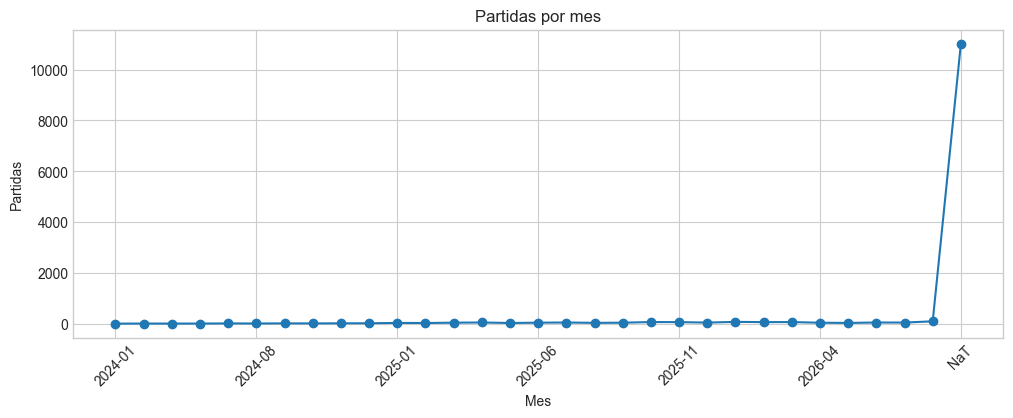

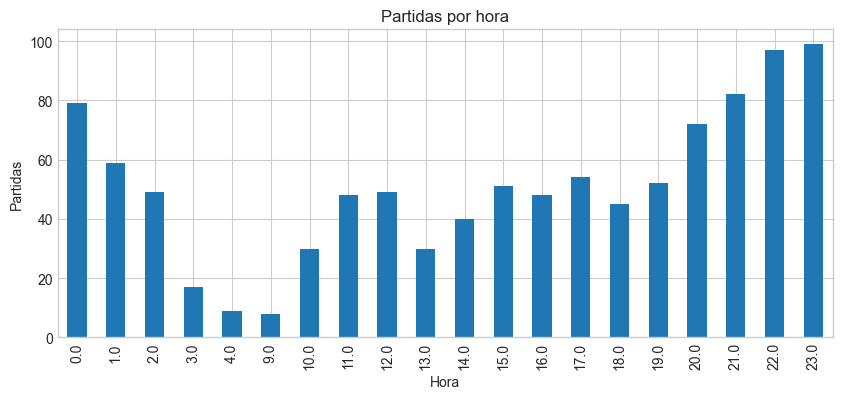

In [7]:
if not matches.empty and 'played_at' in matches.columns:
    matches['month'] = matches['played_at'].dt.to_period('M').astype(str)
    matches['weekday'] = matches['played_at'].dt.day_name()
    matches['hour'] = matches['played_at'].dt.hour
    matches_by_month = matches.groupby('month').size().rename('matches')
    matches_by_month.plot(kind='line', marker='o', figsize=(12, 4), title='Partidas por mes')
    plt.ylabel('Partidas')
    plt.xlabel('Mes')
    plt.xticks(rotation=45)
    plt.show()

    matches_by_hour = matches.groupby('hour').size()
    matches_by_hour.plot(kind='bar', figsize=(10, 4), title='Partidas por hora')
    plt.ylabel('Partidas')
    plt.xlabel('Hora')
    plt.show()

## 6. Actividad por mapa y dificultad

Esta sección relaciona mapa, número de partidas, duración, muertes, daño y vida final. No se debe afirmar que un mapa causa abandono sin un análisis adicional.

,partidas,duracion_promedio,muertes,dano_promedio
map_name,,,,
Calle Vacía,4492,324.658504,2486,49.167186
Habitación,2933,331.441186,1635,49.155131
Hospital,1683,332.632799,921,49.661319
Recuerdo,1120,328.181250,585,49.425893
Callejón,1114,329.342011,605,49.749551
Refugio,680,327.575000,387,49.538235
Mapa 2 - Subterráneo,9,399.111111,7,131.111111
Mapa 1 - Neón City,5,354.800000,4,167.600000
Mapa 3 - Abismo,4,218.250000,3,135.750000


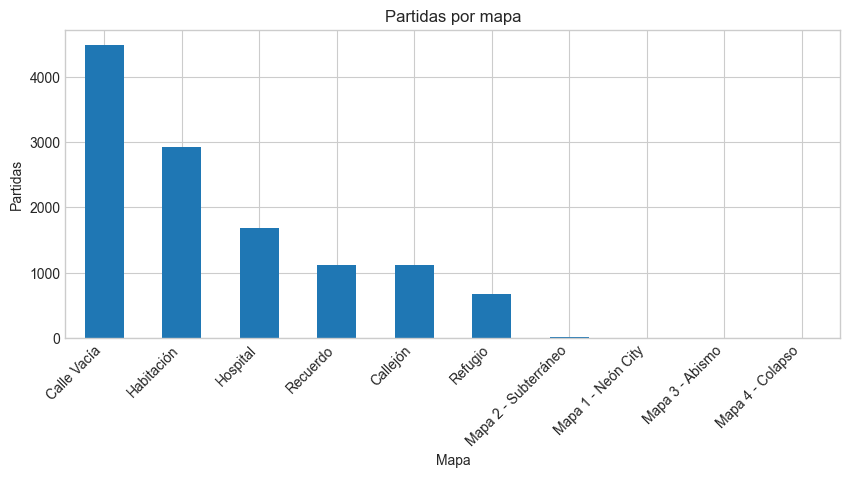

In [8]:
if not matches.empty and 'map_name' in matches.columns:
    map_summary = matches.groupby('map_name').agg(
        partidas=('map_name', 'size'),
        duracion_promedio=('duration_seconds', 'mean'),
        muertes=('death_type', lambda values: values.notna().sum()),
        dano_promedio=('damage_received', 'mean'),
    ).sort_values('partidas', ascending=False)
    display(map_summary)
    map_summary['partidas'].plot(kind='bar', figsize=(10, 4), title='Partidas por mapa')
    plt.ylabel('Partidas')
    plt.xlabel('Mapa')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## 7. Retención

La retención se define como el porcentaje de jugadores registrados que tiene al menos una partida dentro de una ventana de días posterior a su registro.

,days,users,retained,retention_pct
0,1,1007,0,0.0
1,7,1007,0,0.0
2,30,1007,0,0.0


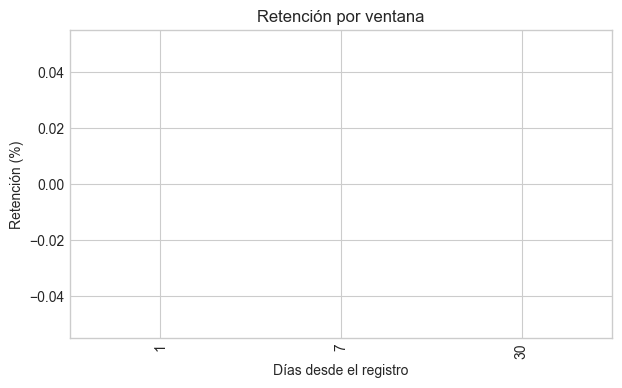

In [9]:
def retention_table(profiles_frame, matches_frame, windows=(1, 7, 30)):
    required_profiles = {'id', 'created_at'}
    required_matches = {'user_id', 'played_at'}
    if profiles_frame.empty or matches_frame.empty:
        return pd.DataFrame(columns=['days', 'users', 'retained', 'retention_pct'])
    if not required_profiles.issubset(profiles_frame.columns) or not required_matches.issubset(matches_frame.columns):
        print('Faltan columnas para calcular retención.')
        return pd.DataFrame()
    registration = profiles_frame.set_index('id')['created_at']
    valid = matches_frame[matches_frame['user_id'].isin(registration.index)].copy()
    valid['registered_at'] = valid['user_id'].map(registration)
    valid['days_after_registration'] = (valid['played_at'] - valid['registered_at']).dt.total_seconds() / 86400
    rows = []
    total_users = len(profiles_frame)
    for days in windows:
        retained = valid.loc[valid['days_after_registration'].between(0, days), 'user_id'].nunique()
        rows.append({'days': days, 'users': total_users, 'retained': retained, 'retention_pct': retained / total_users * 100 if total_users else 0})
    return pd.DataFrame(rows)

retention = retention_table(profiles, matches)
display(retention)
if not retention.empty:
    retention.plot(x='days', y='retention_pct', kind='bar', legend=False, figsize=(7, 4), title='Retención por ventana')
    plt.ylabel('Retención (%)')
    plt.xlabel('Días desde el registro')
    plt.show()

## 8. Monetización y KPI

Se calculan ingresos, compras, ticket promedio y tasa de conversión a compra. La utilidad y el margen no pueden calcularse porque el modelo actual no contiene costos.

In [10]:
kpis = {}
if not profiles.empty and 'id' in profiles.columns:
    kpis['usuarios'] = profiles['id'].nunique()
if not purchases.empty:
    kpis['compras'] = len(purchases)
    kpis['ingresos'] = purchases['price_paid'].sum() if 'price_paid' in purchases else None
    kpis['ticket_promedio'] = purchases['price_paid'].mean() if 'price_paid' in purchases else None
    compradores = purchases['user_id'].nunique() if 'user_id' in purchases else 0
    kpis['tasa_conversion_pct'] = compradores / kpis.get('usuarios', 0) * 100 if kpis.get('usuarios', 0) else 0
if not matches.empty:
    kpis['partidas'] = len(matches)
    kpis['jugadores_activos'] = matches['user_id'].nunique() if 'user_id' in matches else 0

display(pd.Series(kpis, name='valor').to_frame())

,valor
usuarios,1007.000000
compras,682.000000
ingresos,74156.550000
ticket_promedio,108.733944
tasa_conversion_pct,47.765641
partidas,12043.000000
jugadores_activos,1002.000000


## 9. Mecanismo analítico: segmentación de jugadores

Se agrupan los jugadores según su actividad y monetización. El objetivo es identificar jugadores nuevos, ocasionales, recurrentes, comprometidos y compradores para proponer decisiones específicas.

Variables utilizadas:

- Número de partidas.
- Tiempo total de juego.
- Días desde el registro.
- Última actividad.
- Número de compras.
- Gasto total.

La segmentación es descriptiva y no demuestra causalidad. Los resultados deben interpretarse junto con las limitaciones del dataset.

,jugadores,partidas_promedio,tiempo_promedio_seg,compras_promedio,gasto_promedio
segmento,,,,,
Comprador,389,5.658098,1861.848329,1.426735,147.533805
Ocasional,235,2.114894,706.889362,0.000000,0.000000
Recurrente,186,10.387097,3422.494624,0.000000,0.000000
Comprometido,100,39.710000,12980.120000,0.000000,0.000000
Alto valor,92,37.413043,12277.260870,1.380435,182.238043
Nuevo o sin actividad,5,0.000000,0.000000,0.000000,0.000000


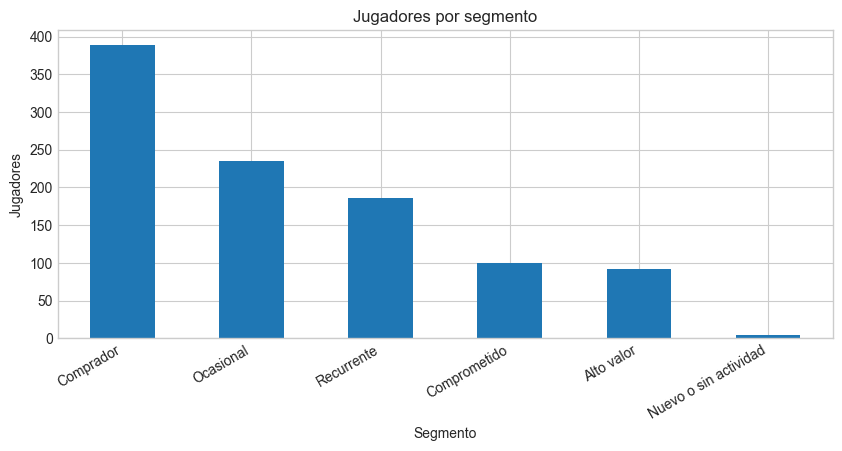

Interpretación pendiente: compara el tamaño, actividad y gasto de cada segmento antes de proponer acciones.


In [11]:
if profiles.empty or 'id' not in profiles.columns:
    player_segments = pd.DataFrame()
    print('PENDIENTE: se necesitan perfiles para calcular segmentos.')
elif matches.empty and purchases.empty:
    player_segments = profiles[['id', 'created_at']].copy()
    print('DATOS INSUFICIENTES: se necesitan game_matches.csv o purchases.csv para segmentar jugadores.')
    print('No se genera una gráfica porque todos los perfiles aparecerían como Nuevo o sin actividad.')
else:
    player_segments = profiles[['id', 'created_at']].copy()
    player_segments = player_segments.rename(columns={'id': 'user_id', 'created_at': 'registered_at'})
    player_segments['registered_at'] = pd.to_datetime(player_segments['registered_at'], errors='coerce', utc=True)

    if not matches.empty and 'user_id' in matches.columns:
        match_summary = matches.groupby('user_id').agg(
            partidas=('user_id', 'size'),
            tiempo_total_seg=('duration_seconds', 'sum'),
            ultima_partida=('played_at', 'max'),
        ).reset_index()
        match_summary['ultima_partida'] = pd.to_datetime(match_summary['ultima_partida'], errors='coerce', utc=True)
        player_segments = player_segments.merge(match_summary, on='user_id', how='left')

    if not purchases.empty and 'user_id' in purchases.columns:
        purchase_summary = purchases.groupby('user_id').agg(
            compras=('user_id', 'size'),
            gasto_total=('price_paid', 'sum'),
        ).reset_index()
        player_segments = player_segments.merge(purchase_summary, on='user_id', how='left')

    for column in ['partidas', 'tiempo_total_seg', 'compras', 'gasto_total']:
        if column not in player_segments.columns:
            player_segments[column] = 0
        player_segments[column] = player_segments[column].fillna(0)

    if 'ultima_partida' not in player_segments.columns:
        player_segments['ultima_partida'] = pd.Series(pd.NaT, index=player_segments.index, dtype='datetime64[ns, UTC]')
    else:
        player_segments['ultima_partida'] = pd.to_datetime(player_segments['ultima_partida'], errors='coerce', utc=True)

    reference_time = pd.Timestamp.now(tz='UTC')
    player_segments['dias_desde_registro'] = (
        reference_time - player_segments['registered_at']
    ).dt.total_seconds().div(86400).clip(lower=0)
    player_segments['dias_desde_ultima_partida'] = (
        reference_time - player_segments['ultima_partida']
    ).dt.total_seconds().div(86400)

    def assign_segment(row):
        if row['compras'] > 0 and row['partidas'] >= 18:
            return 'Alto valor'
        if row['compras'] > 0:
            return 'Comprador'
        if row['partidas'] >= 18:
            return 'Comprometido'
        if row['partidas'] >= 5:
            return 'Recurrente'
        if row['partidas'] >= 1:
            return 'Ocasional'
        return 'Nuevo o sin actividad'

    player_segments['segmento'] = player_segments.apply(assign_segment, axis=1)
    segment_summary = player_segments.groupby('segmento').agg(
        jugadores=('user_id', 'nunique'),
        partidas_promedio=('partidas', 'mean'),
        tiempo_promedio_seg=('tiempo_total_seg', 'mean'),
        compras_promedio=('compras', 'mean'),
        gasto_promedio=('gasto_total', 'mean'),
    ).sort_values('jugadores', ascending=False)

    display(segment_summary)
    segment_summary['jugadores'].plot(kind='bar', figsize=(10, 4), title='Jugadores por segmento')
    plt.ylabel('Jugadores')
    plt.xlabel('Segmento')
    plt.xticks(rotation=30, ha='right')
    plt.show()

    print('Interpretación pendiente: compara el tamaño, actividad y gasto de cada segmento antes de proponer acciones.')

## 10. Hallazgos y decisiones

Completa esta sección después de ejecutar el notebook. Cada hallazgo debe responder:

1. ¿Qué se observa?
2. ¿Qué significa para TRIP?
3. ¿Qué causa posible puede explicarlo?
4. ¿Qué decisión o recomendación se justifica?
5. ¿Qué limitación debe reconocerse?

No presentes una correlación como causalidad y no copies interpretaciones sin verificarlas contra los valores obtenidos.

In [12]:
# Guarda una copia del resumen para incorporarlo al reporte ejecutivo.
summary = pd.DataFrame([kpis])
summary.to_csv(PROCESSED_DIR / 'eda_kpi_summary.csv', index=False)
print(f'Resumen guardado en {PROCESSED_DIR / "eda_kpi_summary.csv"}')

Resumen guardado en ..\data\processed\eda_kpi_summary.csv
